<a href="https://colab.research.google.com/github/sebitajuniorprogramax-byte/nube-palabras-cafe/blob/main/Quetegustadelcafe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Conexión exitosa. Analizando columna: 'Cómo te gusta el café'


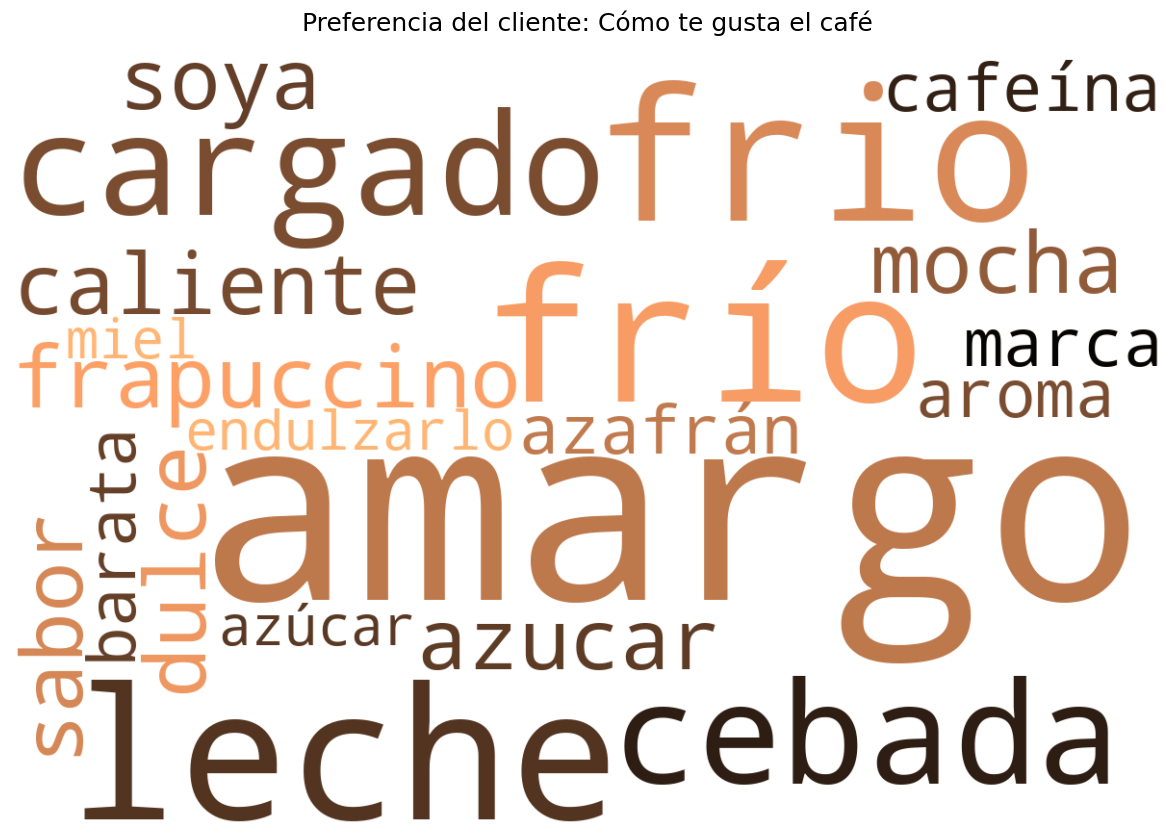

In [ ]:
# =================================================================
# 1. autenticación y librerias
# =================================================================
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re
import nltk
from nltk.corpus import stopwords

# Recursos para procesamiento de lenguaje natural (NLP)
nltk.download('stopwords')

# =================================================================
# 2. CONEXIÓN ROBUSTA A GOOGLE SHEETS
# =================================================================
creds, _ = default()
gc = gspread.authorize(creds)

# Usamos el nombre exacto del archivo
nombre_archivo = 'Que te gusta más del café (Respuestas)'

try:
    spreadsheet = gc.open(nombre_archivo)
    sheet = spreadsheet.get_worksheet(0)
    df = pd.DataFrame(sheet.get_all_records())

    columna_datos = df.columns[1]
    print(f"Conexión exitosa. Analizando columna: '{columna_datos}'")

except Exception as e:
    print(f"Error de conexión: {e}")

# =================================================================
# 3. FILTRADO Y LIMPIEZA PROFESIONAL (ANALISIS DE DATOS)
# =================================================================
def limpiar_respuestas(dataframe, nombre_col):
    # Unimos todo el texto
    texto = " ".join(dataframe[nombre_col].astype(str)).lower()

    # Limpieza de caracteres especiales y números
    texto = re.sub(r'[^a-záéíóúñ\s]', '', texto)

    # Configuración de Stop Words (Palabras de relleno)
    stop_words = set(stopwords.words('spanish'))

    # Agregamos palabras de relleno detectadas
    relleno_especifico = [
        'favorito', 'masomenos', 'dos', 'cucharadas', 'con', 'del', 'que',
        'para', 'una', 'este', 'esta', 'los', 'las', 'como', 'gustar', 'cafe', 'hace', 'suelo', 'rica', 'café', 'cafés', 'gusta', 'encanta', 'ecco', 'manera', 'bien'
    ]
    stop_words.update(relleno_especifico)

    # Filtrado final
    palabras_limpias = [w for w in texto.split() if w not in stop_words and len(w) > 2]
    return " ".join(palabras_limpias)

texto_para_nube = limpiar_respuestas(df, columna_datos)

# =================================================================
# 4. GENERACIÓN DE LA NUBE DE PALABRAS
# =================================================================
# Colores personalizados (Paleta "Copper" para estética de cafetería)
wc = WordCloud(
    width=1200,
    height=800,
    background_color='white',
    colormap='copper',
    max_words=50,
    contour_width=2,
    contour_color='saddlebrown'
).generate(texto_para_nube)

# Visualización
plt.figure(figsize=(15, 10))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title(f"Preferencia del cliente: {columna_datos}", fontsize=18, pad=20)
plt.show()

# Guardar automáticamente para redes sociales
wc.to_file("resultado_cafeteria.png")